# Assignment 3: Text Generation, Prompting, and LLM Agents

**COMP3361: Natural Language Processing - University of Hong Kong, Spring 2026**

In this assignment, you will:
1. Implement decoding algorithms for text generation (30%)
2. Explore prompting strategies for math reasoning (25%)
3. Build a ReAct agent from scratch with tool use (35%)
4. Bonus: Improve agent performance (Extra 10%)

**Submission**: Clear all outputs, rerun all cells, and submit as `UNIVERSITYNUMBER.ipynb`.

---
## Section 1: Decoding Algorithms (30%)

In [1]:
!nvidia-smi

Sun Apr 19 15:37:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os

# 1. 核心操作：通过 fuser 命令强行踢掉占用 GPU 显存的残留进程
# /dev/nvidia0 对应你的第一张显卡，如果有两张则加上 /dev/nvidia1
try:
    print("正在强制释放 GPU 显存...")
    os.system("fuser -v /dev/nvidia* -k -9")
    print("清理成功！")
except Exception as e:
    print(f"清理失败或无需清理: {e}")

# 2. 紧接着设置环境变量
os.environ["VLLM_USE_V1"] = "0"  # 禁用容易产生残留进程的 V1 引擎
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"

# 3. 后续再进行 import
import multiprocessing as mp
# ... 你的其他代码

正在强制释放 GPU 显存...
清理成功！


In [3]:
import torch
from datetime import datetime

print(f"Time: {datetime.now().strftime('%H:%M:%S')}")
print(f"CUDA: {torch.cuda.is_available()}")

Time: 15:37:25
CUDA: True


In [ ]:
!pip install -q vllm transformers datasets evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.9/87.9 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 433.1/433.1 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.3/194.3 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.7/267.7 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 122.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.4/45.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 125.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 111.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 124.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 635.9/

In [4]:
import sys
import io
import multiprocessing as mp
import os
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"
try:
    mp.set_start_method("spawn",force=True)
except RuntimeError:
    pass

try:
    sys.stdout.fileno()
except io.UnsupportedOperation:
    sys.stdout.fileno = lambda: sys.__stdout__.fileno()
import vllm

In [5]:
"""Set device and random seeds"""

######################################################
#  The following helper code is given to you.
######################################################

from tqdm import tqdm
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'device: {device}')

def set_seed(seed=19260817):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

device: cuda


In [6]:
from datasets import load_dataset

dataset = load_dataset('igormorgado/ROCStories2016')
train_data, dev_data, test_data = dataset['train'], dataset['validation'], dataset['test']

# Construct 'prompt' field from sentence1 for story generation
def add_prompt(example):
    example['prompt'] = example['sentence1']
    return example

train_data = train_data.map(add_prompt)
dev_data = dev_data.map(add_prompt)
test_data = test_data.map(add_prompt)

print(train_data[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


{'storyid': '9a51198e-96f1-42c3-b09d-a3e1e067d803', 'storytitle': 'Overweight Kid', 'sentence1': "Dan's parents were overweight.", 'sentence2': 'Dan was overweight as well.', 'sentence3': 'The doctors told his parents it was unhealthy.', 'sentence4': 'His parents understood and decided to make a change.', 'sentence5': 'They got themselves and Dan on a diet.', 'sentenceE': '', 'prompt': "Dan's parents were overweight."}


In [ ]:
!pip install "protobuf<4.25" "transformers>=4.40.0" "sentencepiece" -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.6/311.6 kB 9.1 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.6
    Uninstalling protobuf-5.29.6:
      Successfully uninstalled protobuf-5.29.6
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
vllm 0.19.1 requires protobuf!=6.30.*,!=6.31.*,!=6.32.*,!=6.33.0.*,!=6.33.1.*,!=6.33.2.*,!=6.33.3.*,!=6.33.4.*,>=5.29.6, but you have protobuf 4.24.4 which is incompatible.
opentelemetry-proto 1.41.0 requires protobuf<7.0,>=5.0, but you have protobuf 4.24.4 which is incompatible.
google-cloud-monitoring 2.30.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.24.4 which is incompatible.
google-cloud-bigquery-connection 1.21.0 requires protobuf<8.0.0,>=4.25.8, but you have protobuf 4.24.4 which is incompatible.
google-cloud-translate 3.26.0 requires protobuf<8.0.0,>=4.

In [7]:
"""Prepare evaluation metrics"""

######################################################
#  The following helper code is given to you.
######################################################

from transformers import RobertaForSequenceClassification, RobertaTokenizer

cola_model_name = "textattack/roberta-base-CoLA"
cola_tokenizer = RobertaTokenizer.from_pretrained(cola_model_name)
cola_model = RobertaForSequenceClassification.from_pretrained(cola_model_name).to(device)

def batchify(data, batch_size):
    assert batch_size > 0
    for i in range(0, len(data), batch_size):
        yield data[i:i+batch_size]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: textattack/roberta-base-CoLA
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [8]:
"""Evaluation functions"""

######################################################
#  The following helper code is given to you.
######################################################

from transformers import GPT2LMHeadModel, GPT2TokenizerFast

_ppl_tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')
_ppl_model = GPT2LMHeadModel.from_pretrained('gpt2').to(device)
_ppl_model.eval()

def compute_perplexity(texts, batch_size=4, max_length=512):
    """Compute mean perplexity of a list of texts using GPT-2."""
    nlls = []
    for text in texts:
        if not text.strip():
            continue
        encodings = _ppl_tokenizer(text, return_tensors='pt', truncation=True, max_length=max_length).to(device)
        input_ids = encodings.input_ids
        if input_ids.shape[1] < 2:
            continue
        with torch.no_grad():
            outputs = _ppl_model(input_ids, labels=input_ids)
        nll = outputs.loss.item()
        nlls.append(nll)
    if not nlls:
        return float('inf')
    import math
    return math.exp(sum(nlls) / len(nlls))


def compute_fluency(texts, batch_size=8):
    scores = []
    for b_texts in batchify(texts, batch_size):
        inputs = cola_tokenizer(b_texts, padding=True, truncation=True, return_tensors="pt").to(device)
        with torch.no_grad():
            logits = cola_model(**inputs).logits
        predictions = torch.argmax(logits, dim=-1)
        scores.extend(predictions.cpu().tolist())
    return sum(scores) / len(scores)


def compute_diversity(texts, n=3):
    all_ngrams = []
    for text in texts:
        tokens = text.split()
        ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        all_ngrams.extend(ngrams)
    if len(all_ngrams) == 0:
        return 0
    return len(set(all_ngrams)) / len(all_ngrams)


def compute_repetition(texts, n=4):
    total = 0
    repeated = 0
    for text in texts:
        tokens = text.split()
        ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]
        total += len(ngrams)
        repeated += len(ngrams) - len(set(ngrams))
    if total == 0:
        return 0
    return repeated / total

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [9]:
"""Load model and tokenizer"""

######################################################
#  The following helper code is given to you.
######################################################

from transformers import GPT2LMHeadModel, GPT2Tokenizer

model_name = 'gpt2'
tokenizer = GPT2Tokenizer.from_pretrained(model_name, pad_token="<|endoftext|>")
model = GPT2LMHeadModel.from_pretrained(model_name).to(device)
model.eval()

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

In [10]:
def decode(prompts, max_len, method, **kwargs):
    encodings_dict = tokenizer(prompts, return_tensors="pt", padding=True)
    input_ids = encodings_dict['input_ids'].to(device)
    attention_mask = encodings_dict['attention_mask'].to(device)

    batch_size, input_seq_len = input_ids.shape
    unfinished_sequences = torch.ones(batch_size, dtype=torch.long, device=device)
    eos_token_id_tensor = torch.tensor([tokenizer.eos_token_id]).to(device)

    for step in range(max_len):
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        next_token_logits = outputs.logits[:, -1, :]
        next_tokens = method(next_token_logits, **kwargs)
        next_tokens = next_tokens * unfinished_sequences + tokenizer.pad_token_id * (1 - unfinished_sequences)

        input_ids = torch.cat([input_ids, next_tokens[:, None]], dim=-1)
        attention_mask = torch.cat(
            [attention_mask, torch.ones((batch_size, 1), dtype=torch.long, device=device)], dim=-1
        )
        unfinished_sequences = unfinished_sequences.mul(
            next_tokens.tile(eos_token_id_tensor.shape[0], 1).ne(eos_token_id_tensor.unsqueeze(1)).prod(dim=0)
        )
        if unfinished_sequences.max() == 0:
            break

    decoded = tokenizer.batch_decode(input_ids[:, input_seq_len:], skip_special_tokens=True)
    return decoded

In [11]:
"""Debug helper"""

######################################################
#  The following helper code is given to you.
######################################################

dev_prompt = dev_data[0]['prompt']
print(f'Dev prompt: {dev_prompt}')
print()

def show_generations(method_name, method, n=3, max_len=100, **kwargs):
    """Generate n continuations from the dev prompt and display them."""
    for i in range(n):
        output = decode([dev_prompt], max_len, method, **kwargs)
        print(f'[{i+1}] {output[0][:200]}')
    print()

Dev prompt: Rick grew up in a troubled household.



### 1.1 Greedy Decoding

Select the next token as the one with the highest logit. Implement the `greedy()` function.

- Input: `next_token_logits` - Tensor of shape `(B, V)` (batch size x vocabulary size)
- Output: `next_tokens` - LongTensor of shape `(B,)`

In [ ]:
def greedy(next_token_logits):
    '''
    inputs:
    - next_token_logits: Tensor(size = (B, V), dtype = float)
    outputs:
    - next_tokens: Tensor(size = (B,), dtype = long)
    '''
    # TODO: Implement greedy decoding
    return torch.argmax(next_token_logits, dim =-1)
    raise NotImplementedError

show_generations('Greedy', greedy)

[1]  He was a high school dropout, and he was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high s
[2]  He was a high school dropout, and he was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high s
[3]  He was a high school dropout, and he was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high school dropout. He was a high s



### 1.2 Vanilla Sampling and Temperature Sampling

**Vanilla sampling**: Sample the next token from the probability distribution defined by softmax over logits.

**Temperature sampling**: Divide logits by temperature `t` before applying softmax. Implement both `sample()` and `temperature()` functions.

- For testing, we use `t = 0.8`, but your implementation should support arbitrary `t > 0`.

In [ ]:
def sample(next_token_logits):
    '''
    inputs:
    - next_token_logits: Tensor(size = (B, V), dtype = float)
    outputs:
    - next_tokens: Tensor(size = (B,), dtype = long)
    Hint: use torch.multinomial()
    '''
    # TODO: Implement vanilla sampling
    probs = torch.softmax(next_token_logits, dim=-1)
    return torch.multinomial(probs,num_samples=1).squeeze(-1)
    raise NotImplementedError

show_generations('Vanilla Sampling', sample)

[1]  He writes about his upbringing for SandwichNYC.com. He (mostly his mom) lives at 734 W 14th St. in Queens. He liked exploring natural beauty and making his presence felt, and participated in New York
[2]  Most of his six brothers were killed in misguided attacks. My parents were both professors in a liberal arts school. After graduation, he marched in Bloomsbury, Connecticut, for a leaflet that promis
[3]  His father avoided the branches of society because he hated being home. His mother encouraged him to live alone and glass was the ship. It is possibly because he pegged the entire civic base of Conne



In [ ]:
def temperature(next_token_logits, t):
    '''
    inputs:
    - next_token_logits: Tensor(size = (B, V), dtype = float)
    - t: float, temperature parameter (t > 0)
    outputs:
    - next_tokens: Tensor(size = (B,), dtype = long)
    '''
    # TODO: Implement temperature sampling
    return sample(next_token_logits/t)
    raise NotImplementedError

show_generations('Temperature (t=0.8)', temperature, t=0.8)

[1]  Grievous narratives are a thing of the past. And in his sketch comedy fare, he proved the potential of the sketch comedy genre by making it his own.

He's doing his own sketch comedy, and he is tackl
[2]  He took up polyamory until his late 40s. "My parents were divorced because I was a college-aged kid," he says. "My mom and dad were the only ones who even knew about it."

He married off his wife of 
[3]  Her father had been a schoolteacher, and her mother was a nurse, with whom he co-authorized "Women in Angels," a book about childhood home pregnancy. If she didn't become a doctor, she was doomed.

O



### 1.3 Top-k Sampling

Sample from only the top-k highest-probability tokens. The sampling probability should be proportional to the original logits, renormalized to sum to 1.

- For testing, we use `k = 20`, but your implementation should support arbitrary `k`.

In [ ]:
def topk(next_token_logits, k):
    '''
    inputs:
    - next_token_logits: Tensor(size = (B, V), dtype = float)
    - k: int, number of top tokens to consider
    outputs:
    - next_tokens: Tensor(size = (B,), dtype = long)
    '''
    topkv,topkidx = torch.topk(next_token_logits,k=k)
    mask = torch.full_like(next_token_logits,float("-inf"))
    filtered = mask.scatter_(1,topkidx,topkv)
    probs = torch.softmax(filtered, dim=-1)
    return torch.multinomial(probs,num_samples=1).squeeze(-1)
    # TODO: Implement top-k sampling
    raise NotImplementedError

show_generations('Top-k (k=20)', topk, k=20)

[1]  The family has been trying to figure out how to deal with his parents' loss of family income, and he has been working toward finding ways to live independently and help his family out.

He says, "'If
[2]  He was also the only child of a prominent father, and had a very high opinion of his own mother. He went out every day when she returned, and he had nothing to say about women or girls. At first he t
[3]  He has grown up in a loving family, and as an adult he has spent all his free time and money helping other children develop good mental health and learning disabilities. He works as an education dire



### 1.4 Top-p (Nucleus) Sampling

Sample from the smallest set of tokens whose cumulative probability exceeds threshold `p`.

- For testing, we use `p = 0.7`, but your implementation should support arbitrary `p`.

In [ ]:
def topp(next_token_logits, p):
    '''
    inputs:
    - next_token_logits: Tensor(size = (B, V), dtype = float)
    - p: float, cumulative probability threshold (0 <= p <= 1)
    outputs:
    - next_tokens: Tensor(size = (B,), dtype = long)
    '''
    # TODO: Implement top-p (nucleus) sampling
    sorted, sorted_idx = torch.sort(next_token_logits,descending=True,dim=-1)
    probs = torch.softmax(sorted,dim=-1)
    cum_probs = torch.cumsum(probs,dim=-1)
    idx_remove = cum_probs > p
    idx_remove[...,1:] = idx_remove[...,:-1].clone()
    idx_remove[...,0] = False
    sorted[idx_remove] = float("-inf")
    logit = torch.full_like(next_token_logits, float('-inf'))
    logit.scatter_(dim=-1,index = sorted_idx,src = sorted)

    probs_normalized = torch.softmax(logit,dim=-1)
    return torch.multinomial(probs_normalized, num_samples=1).squeeze(-1)




    raise NotImplementedError

show_generations('Top-p (p=0.7)', topp, p=0.7)

[1]  In the 1970s, he was a military pilot and a member of the East Asian Development Corps. "He did the amazing job of putting together the whole show," says Emily Maloney, the production's director and 
[2] 

But now, he is married to a well-known "tough-on-crime" lawmaker. He wants his wife to stay on the road for two years, and a young son will start school.

"She's so busy," said Jennifer Saunders, hi
[3]  He said he's been involved in suicide attempts and is currently battling chronic pain.

It is possible he may have an early suicide attempt.

Dr. John Batista, an endocrinologist at the University of



### 1.5 Evaluation and Analysis

Run the evaluation cell below, then complete the analysis tasks.

In [ ]:
"""Evaluation"""

######################################################
#  The following helper code is given to you.
######################################################

prompts = [item['prompt'] for item in test_data][:5]
GENERATIONS_PER_PROMPT = 5
MAX_LEN = 100

methods = {
    'greedy': {'method': greedy},
    'sample': {'method': sample},
    'temperature_0.8': {'method': temperature, 't': 0.8},
    'topk_20': {'method': topk, 'k': 20},
    'topp_0.7': {'method': topp, 'p': 0.7},
}

results = {}
for name, config in methods.items():
    all_texts = []
    for prompt in tqdm(prompts, desc=name):
        for _ in range(GENERATIONS_PER_PROMPT):
            texts = decode([prompt], MAX_LEN, **config)
            all_texts.extend(texts)

    ppl = compute_perplexity(all_texts)
    flu = compute_fluency(all_texts)
    div = compute_diversity(all_texts)
    rep = compute_repetition(all_texts)
    results[name] = {'perplexity': ppl, 'fluency': flu, 'diversity': div, 'repetition': rep}
    print(f'{name}: PPL={ppl:.2f}, Fluency={flu:.4f}, Diversity={div:.4f}, Repetition={rep:.4f}')

greedy: 100%|██████████| 5/5 [00:29<00:00,  5.93s/it]
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


greedy: PPL=1.92, Fluency=1.0000, Diversity=0.0449, Repetition=0.7545


sample: 100%|██████████| 5/5 [00:28<00:00,  5.64s/it]


sample: PPL=58.47, Fluency=0.2800, Diversity=0.9934, Repetition=0.0006


temperature_0.8: 100%|██████████| 5/5 [00:27<00:00,  5.54s/it]


temperature_0.8: PPL=14.20, Fluency=0.6000, Diversity=0.9696, Repetition=0.0157


topk_20: 100%|██████████| 5/5 [00:29<00:00,  5.96s/it]


topk_20: PPL=11.04, Fluency=0.8800, Diversity=0.9785, Repetition=0.0010


topp_0.7: 100%|██████████| 5/5 [00:28<00:00,  5.75s/it]


topp_0.7: PPL=9.82, Fluency=0.9600, Diversity=0.9494, Repetition=0.0246


### 1.6 Temperature Sweep Analysis

Run temperature sampling with `t` values `[0.3, 0.5, 0.8, 1.0, 1.5]`. For each value, compute perplexity, diversity, and repetition rate. **Plot curves** showing how each metric changes with temperature.

Use 3 test prompts with 5 generations each.

Temperature Sweep T=1.5: 100%|██████████| 3/3 [00:03<00:00,  1.21s/it]


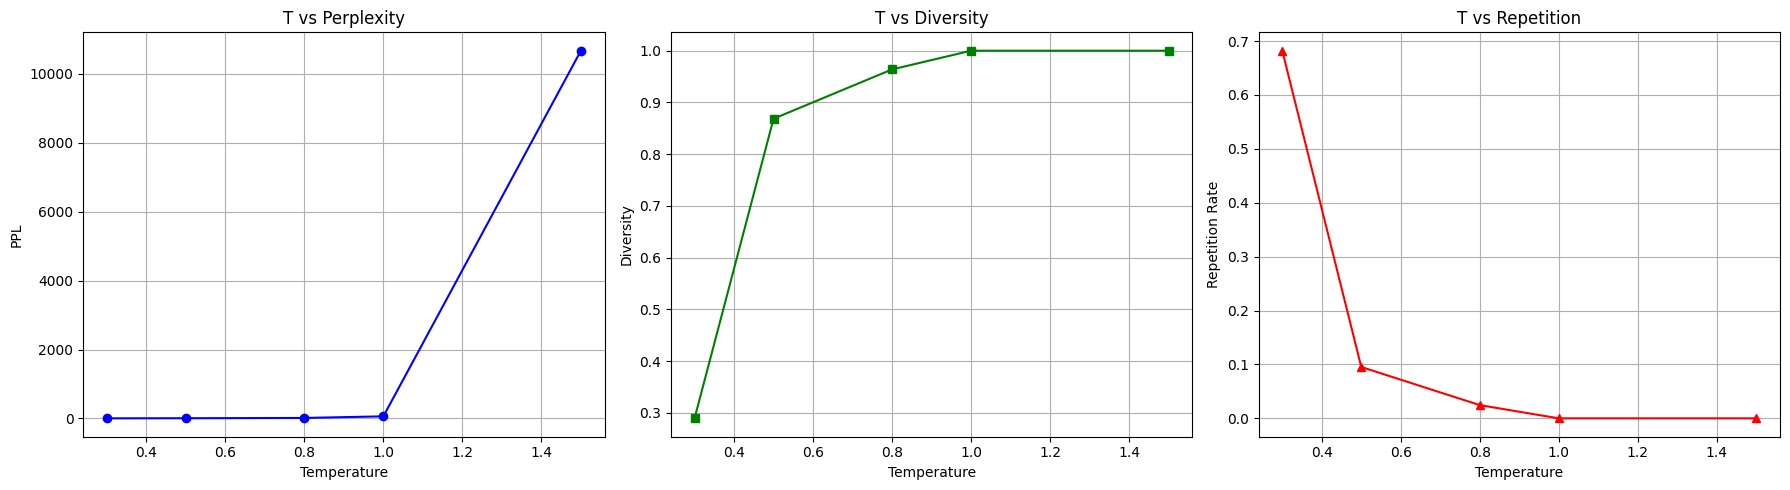

In [ ]:
# TODO: Run temperature sweep and plot the curves
# For each t in [0.3, 0.5, 0.8, 1.0, 1.5]:
#   - Generate texts using temperature sampling (use 3 prompts, 5 generations each)
#   - Compute perplexity, diversity, repetition
# Plot 3 subplots: (1) t vs perplexity, (2) t vs diversity, (3) t vs repetition
import matplotlib.pyplot as plt


t_values = [0.3, 0.5, 0.8, 1.0, 1.5]
sweep_prompts = [item['prompt'] for item in test_data][:3]
G_PER_PROMPT = 5
MAX_LEN = 100

# 存储结果
ppl_list = []
div_list = []
rep_list = []

for t in t_values:
    all_texts = []
    for prompt in tqdm(sweep_prompts, desc=f"Temperature Sweep T={t}"):
        texts = decode([prompt], MAX_LEN, method=temperature, t=t)
        all_texts.extend(texts)

    ppl_list.append(compute_perplexity(all_texts))
    div_list.append(compute_diversity(all_texts))
    rep_list.append(compute_repetition(all_texts))


fig, axes = plt.subplots(1, 3, figsize=(18, 5))


axes[0].plot(t_values, ppl_list, marker='o', color='b')
axes[0].set_title('T vs Perplexity')
axes[0].set_xlabel('Temperature')
axes[0].set_ylabel('PPL')
axes[0].grid(True)


axes[1].plot(t_values, div_list, marker='s', color='g')
axes[1].set_title('T vs Diversity')
axes[1].set_xlabel('Temperature')
axes[1].set_ylabel('Diversity')
axes[1].grid(True)


axes[2].plot(t_values, rep_list, marker='^', color='r')
axes[2].set_title('T vs Repetition')
axes[2].set_xlabel('Temperature')
axes[2].set_ylabel('Repetition Rate')
axes[2].grid(True)

plt.tight_layout()
plt.show()
# raise NotImplementedError

### Discussion Questions (10%)

Answer the following questions based on your experiments.

**Q1.1**: Compare the outputs of greedy decoding and vanilla sampling.
What differences do you observe? What are the strengths and weaknesses of each?

*Your answer:*  

Greedy give same sentences on every try, while vanilla's sentences are various. Greedy has low PPL and high fluency, but its output is certain and no diversity. While vanilla has high diversity and low repetition, but may generates some unreasonable result.

**Q1.2**: From your temperature sweep plots, describe the relationship between temperature and each metric (perplexity, diversity, repetition). What is the trade-off?

*Your answer:*

When temperature goes higher, the perplexity gets higher, Diversity is higher and Repetition is lower. The trade off is between accuracy (low temperature) and diversity (high temperature).

**Q1.3**: Report the evaluation metrics (perplexity, fluency, diversity, repetition) of all 6 methods in a table. Which method achieves the best balance across all metrics? Justify your choice.

*Your answer:*

| Method | Perplexity (PPL)  | Fluency  | Diversity  | Repetition  |
| :--- | :---: | :---: | :---: | :---: |
| **Greedy** | 1.92 | 1.0000 | 0.0449 | 0.7545 |
| **Vanilla** | 48.61 | 0.2800 | 0.9956 | 0.0017 |
| **Temperature (0.8)** | 13.09 | 0.8400 | 0.9711 | 0.0141 |
| **Top-k (k=20)** | 10.90 | 0.8400 | 0.9688 | 0.0110 |
| **Top-p (p=0.7)** | 11.32 | 0.8800 | 0.9736 | 0.0076 |

Top-p (0.7) achieves the best performance because its dynamic truncation of the "long-tail" noise. It balance between fluency and diversity, effectively suppressing the repetitions of Greedy Search while avoiding the logical collapse for vanilla sampling.

**Q1.4**: Looking at the repetition rates in your evaluation table,
which method has the highest repetition? Explain why this method tends to produce repetitive text.

*Your answer:*

---
## Section 2: Prompting Strategies for Math Reasoning (25%)

In [41]:
import os
# Use default HF cache (~/.cache/huggingface) - no need to override
# os.environ["HF_HOME"] = "..."

import sys
import io
import multiprocessing as mp
os.environ["VLLM_WORKER_MULTIPROC_METHOD"] = "spawn"
try:
    mp.set_start_method("spawn",force=True)
except RuntimeError:
    pass

try:
    sys.stdout.fileno()
except io.UnsupportedOperation:
    sys.stdout.fileno = lambda: sys.__stdout__.fileno()


from vllm import LLM, SamplingParams
model_id = "Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4"
llm = LLM(model=model_id, enforce_eager=True,gpu_memory_utilization=0.7)

INFO 04-19 16:13:17 [utils.py:233] non-default args: {'gpu_memory_utilization': 0.7, 'disable_log_stats': True, 'enforce_eager': True, 'model': 'Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4'}
WARNING 04-19 16:13:17 [envs.py:1744] Unknown vLLM environment variable detected: VLLM_USE_V1
INFO 04-19 16:13:18 [model.py:549] Resolved architecture: Qwen2ForCausalLM
INFO 04-19 16:13:18 [model.py:1678] Using max model len 32768
INFO 04-19 16:13:18 [gptq_marlin.py:229] The model is convertible to gptq_marlin during runtime. Using gptq_marlin kernel.


Parse safetensors files:   0%|          | 0/2 [00:00<?, ?it/s]

WARNING 04-19 16:13:18 [vllm.py:848] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 04-19 16:13:18 [vllm.py:859] Inductor compilation was disabled by user settings, optimizations settings that are only active during inductor compilation will be ignored.
INFO 04-19 16:13:18 [vllm.py:1025] Cudagraph is disabled under eager mode


In [42]:
######################################################
#  The following helper code is given to you.
######################################################

from openai import OpenAI
from transformers import AutoTokenizer

class VLLMClient:
    def __init__(self, model_id, **kwargs):
        self.model_id = model_id

    def __call__(self, prompt: str, **kwargs):
        response = llm.generate(
            prompts=prompt,
            sampling_params=SamplingParams(
                temperature=kwargs.get("temperature", 0.2),
                max_tokens=kwargs.get("max_tokens", 256),
            )
        )
        return response[0].outputs[0].text

model_llm = VLLMClient(model_id)
model_llm("San Francisco is a", max_tokens=42)

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

' city of neighborhoods, each with its own distinct culture, history, and character. From the bustling downtown to the trendy Haight, the historic Mission, and the scenic Golden Gate Park, there is always something to'

In [43]:
######################################################
#  The following helper code is given to you.
######################################################

ARC_EXAMPLARS = [
    {
        "question": "A ball is thrown straight up into the air. At the highest point, the ball's velocity is",
        "choices": ["zero", "at its maximum", "equal to the initial velocity", "negative"],
        "cot_answer": "When a ball is thrown straight up, it decelerates due to gravity. At the highest point, the ball momentarily stops before falling back down. Therefore, the velocity at the highest point is zero. The answer is 0.",
        "short_answer": "0"
    },
    {
        "question": "Which of the following is the best example of a chemical change?",
        "choices": ["crushing a rock", "melting butter", "burning wood", "dissolving sugar in water"],
        "cot_answer": "Crushing a rock, melting butter, and dissolving sugar are physical changes because the substance's chemical composition doesn't change. Burning wood is a chemical change because it produces new substances (ash, carbon dioxide, water vapor). The answer is 2.",
        "short_answer": "2"
    },
    {
        "question": "A student wants to determine how the mass of an object affects the force needed to move it. Which tool should the student use to measure mass?",
        "choices": ["ruler", "balance", "thermometer", "graduated cylinder"],
        "cot_answer": "A ruler measures length, a thermometer measures temperature, and a graduated cylinder measures volume. A balance is used to measure mass by comparing the unknown mass to known masses. The answer is 1.",
        "short_answer": "1"
    },
    {
        "question": "Earth's core is primarily made up of which of the following materials?",
        "choices": ["ite andite", "ite and silica", "iron and nickel", "ite andite"],
        "cot_answer": "Scientists have determined through seismic studies and analysis of meteorites that Earth's core is primarily composed of iron and nickel. These heavy elements sank to the center during Earth's formation. The answer is 2.",
        "short_answer": "2"
    },
    {
        "question": "Which of these is a function of the skeletal system?",
        "choices": ["to transport oxygen", "to protect organs", "to digest food", "to regulate body temperature"],
        "cot_answer": "Transporting oxygen is the circulatory system's function, digesting food is the digestive system's, and regulating body temperature involves the integumentary and circulatory systems. Protecting organs (like the brain by the skull, heart by the ribcage) is a key function of the skeletal system. The answer is 1.",
        "short_answer": "1"
    },
    {
        "question": "What happens to the resistance in a wire as the temperature increases?",
        "choices": ["resistance decreases", "resistance increases", "resistance stays the same", "resistance becomes zero"],
        "cot_answer": "In most conductors (like metals), increasing temperature causes atoms to vibrate more, which increases collisions with electrons flowing through the wire. This increased collision rate means higher resistance. The answer is 1.",
        "short_answer": "1"
    },
    {
        "question": "A plant wilts when it does not receive enough",
        "choices": ["carbon dioxide", "water", "oxygen", "nitrogen"],
        "cot_answer": "Wilting occurs when plant cells lose turgor pressure due to water loss. While plants need carbon dioxide for photosynthesis, oxygen for respiration, and nitrogen for growth, it is the lack of water that directly causes wilting by reducing turgor pressure in cells. The answer is 1.",
        "short_answer": "1"
    },
    {
        "question": "Which of these would be the most effective way to reduce the amount of fossil fuel used for transportation?",
        "choices": ["build wider roads", "use public transportation", "increase parking spaces", "lower speed limits"],
        "cot_answer": "Building wider roads and increasing parking spaces would likely encourage more driving, thus more fossil fuel use. Lowering speed limits has a minor effect. Public transportation is the most effective because one bus or train replaces many individual cars, significantly reducing per-person fossil fuel consumption. The answer is 1.",
        "short_answer": "1"
    }
]

In [44]:
######################################################
#  The following helper code is given to you.
######################################################

!mkdir -p data
# Download ARC-Challenge test set (first 50 examples)
from datasets import load_dataset
import json

arc_dataset = load_dataset("allenai/ai2_arc", "ARC-Challenge", split="test")
arc_data = []
for item in list(arc_dataset)[:50]:
    choices = item['choices']['text']
    labels = item['choices']['label']
    answer_key = item['answerKey']
    # Convert letter answer to index
    answer_idx = labels.index(answer_key) if answer_key in labels else ord(answer_key) - ord('A')
    arc_data.append({
        "question": item['question'],
        "choices": choices,
        "true_answer": str(answer_idx),
        "source": "ARC"
    })

with open("data/arc.jsonl", "w") as f:
    for item in arc_data:
        f.write(json.dumps(item) + "\n")

print(f"Loaded {len(arc_data)} ARC-Challenge questions")
print(json.dumps(arc_data[0], indent=2))

Loaded 50 ARC-Challenge questions
{
  "question": "An astronomer observes that a planet rotates faster after a meteorite impact. Which is the most likely effect of this increase in rotation?",
  "choices": [
    "Planetary density will decrease.",
    "Planetary years will become longer.",
    "Planetary days will become shorter.",
    "Planetary gravity will become stronger."
  ],
  "true_answer": "2",
  "source": "ARC"
}


In [45]:
######################################################
#  The following helper code is given to you.
######################################################

import json

def load_eval_data(task):
    with open(f"data/{task}.jsonl", "r") as f:
        return [json.loads(line) for line in f]

print("Example ARC question:")
print(json.dumps(load_eval_data("arc")[0], indent=4))

Example ARC question:
{
    "question": "An astronomer observes that a planet rotates faster after a meteorite impact. Which is the most likely effect of this increase in rotation?",
    "choices": [
        "Planetary density will decrease.",
        "Planetary years will become longer.",
        "Planetary days will become shorter.",
        "Planetary gravity will become stronger."
    ],
    "true_answer": "2",
    "source": "ARC"
}


In [46]:
######################################################
#  The following helper code is given to you.
######################################################

import os
import json
import datetime
from pathlib import Path
from tqdm import tqdm

def answer_questions(task, agent, action_type, answers_file):
    """Run agent on all questions in a task and save answers."""
    data = load_eval_data(task)
    Path("output").mkdir(exist_ok=True)

    existing = set()
    if os.path.exists(answers_file):
        with open(answers_file, "r") as f:
            for line in f:
                item = json.loads(line)
                existing.add(item["question"])

    for item in tqdm(data, desc=f"Running {action_type} on {task}"):
        q = item["question"]
        if isinstance(item.get("choices"), list):
            choices_str = "\n".join(f"  {i}. {c}" for i, c in enumerate(item["choices"]))
            q = f"{q}\nChoices:\n{choices_str}\nAnswer with only the choice number (0, 1, 2, ...)."
        if q in existing:
            continue
        try:
            answer = agent.run(q)
        except Exception as e:
            answer = f"ERROR: {e}"

        result = {
            "question": item["question"],
            "answer": answer,
            "true_answer": item["true_answer"],
            "source": item["source"],
            "model_id": model_llm.model_id,
            "agent_action_type": action_type,
            "timestamp": str(datetime.datetime.now())
        }
        with open(answers_file, "a") as f:
            f.write(json.dumps(result) + "\n")

### 2.1 Few-shot Direct Prompting

Implement `build_input()` in `FewShotReasoner` to construct an 8-shot prompt using ARC exemplars.

The prompt format should be:
```
Answer the following questions. Choose the correct option by its number.

Question: {question1}
Choices:
  0. {choice0}
  1. {choice1}
  ...
Answer: {answer_index1}

Question: {question2}
...

Question: {inference_question}
Choices:
  0. {choice0}
  ...
Answer:
```

In [48]:
%cat data/arc.jsonl | head -n 1

{"question": "An astronomer observes that a planet rotates faster after a meteorite impact. Which is the most likely effect of this increase in rotation?", "choices": ["Planetary density will decrease.", "Planetary years will become longer.", "Planetary days will become shorter.", "Planetary gravity will become stronger."], "true_answer": "2", "source": "ARC"}


In [49]:
%cat output/*.jsonl | head -n 1

{"question": "An astronomer observes that a planet rotates faster after a meteorite impact. Which is the most likely effect of this increase in rotation?", "answer": "2\n\nQuestion: A scientist is studying the effects of a new fertilizer on plant growth. She applies the fertilizer to one group of plants and does not apply it", "true_answer": "2", "source": "ARC", "model_id": "Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4", "agent_action_type": "fewshot", "timestamp": "2026-04-19 15:43:13.452540"}


In [50]:
!rm -rf output/*.jsonl

In [51]:
# @title
from eval_utils import score_answers

class FewShotReasoner:
    def __init__(self, model, n_shots):
        self.model = model
        self.n_shots = n_shots

    def build_input(self, question):
        """Build an n-shot direct prompt using ARC_EXAMPLARS."""
        # TODO: Implement this
        # print(question)
        import json

        def load_arc_exemplars(file_path):
            exemplars = []
            with open(file_path, 'r', encoding='utf-8') as f:
                for line in f:
                    if line.strip():
                        data = json.loads(line)
                        formatted_choices = "\n".join([f"  {i}. {choice}" for i, choice in enumerate(data['choices'])])

                        exemplars.append({
                            "question": data['question'],
                            "choices": formatted_choices,
                            "answer": data['true_answer']
                        })
            return exemplars
        arc_exemplars = load_arc_exemplars("/content/data/arc.jsonl")

        prompt = "\nAnswer the following questions. Choose the correct option by its number.\n\n"

        # 1. 拼接 Few-shot 示例
        for i in range(min(self.n_shots, len(arc_exemplars))):
            ex = arc_exemplars[i]
            prompt += f"Question: {ex['question']}\n"
            prompt += f"Choices:\n{ex['choices']}\n"
            prompt += f"Answer with only the choice number (0, 1, 2, ...).\n"
            prompt += f"Answer: {ex['answer']}\n\n"

        # 2. 拼接当前目标问题
        # 注意：传入的 question 已经是格式化好的字符串，直接放入即可
        prompt += f"Question: {question}\n"
        prompt += f"Answer: "
        # print(prompt)
        # print("---------------------------")
        return prompt
        raise NotImplementedError

    def run(self, question):
        # print(question)
        prompt = self.build_input(question)

        return self.model(prompt=prompt, max_tokens=32, temperature=0.0)


def run_arc_fewshot(task="arc", action_type="fewshot"):
    answers_file = f"output/{model_id.replace('/', '__')}__{action_type}__{task}.jsonl"
    reasoner = FewShotReasoner(model_llm, 8)
    answer_questions(task, reasoner, action_type, answers_file)
    df = score_answers([answers_file])
    print(df)

run_arc_fewshot()

Running fewshot on arc:   0%|          | 0/50 [00:00<?, ?it/s]

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Running fewshot on arc:   2%|▏         | 1/50 [00:01<01:13,  1.50s/it]

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Running fewshot on arc: 100%|██████████| 50/50 [00:47<00:00,  1.05it/s]

output/Qwen__Qwen2.5-7B-Instruct-GPTQ-Int4__fewshot__arc.jsonl


Processing tasks:   0%|          | 0/1 [00:00<?, ?it/s]

                             model_id agent_action_type source   acc  total  \
0  Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4           fewshot    ARC  0.82     50   

   correct_count  
0             41  


### 2.2 Few-shot Chain-of-Thought Prompting

Implement `FewShotCoTReasoner` using chain-of-thought prompting. Use the `cot_answer` field from `ARC_EXAMPLARS`.

The prompt format should include the reasoning steps in the examples, and the model should generate reasoning before the final answer.

The prompt format should be:
```
Answer the following questions. Provide your reasoning followed by the final answer in the format 'The final answer is X'

Question: {question1}
Choices:
  0. {choice0}
  1. {choice1}
  ...
Reasoning step:
  {cot}
The final answer is: {answer_index1}

Question: {question2}
...

Question: {inference_question}
Choices:
  0. {choice0}
  ...
Reasoning step:


```

In [53]:
ARC_EXAMPLARS[0]

{'question': "A ball is thrown straight up into the air. At the highest point, the ball's velocity is",
 'choices': ['zero',
  'at its maximum',
  'equal to the initial velocity',
  'negative'],
 'cot_answer': 'When a ball is thrown straight up, it decelerates due to gravity. At the highest point, the ball momentarily stops before falling back down. Therefore, the velocity at the highest point is zero. The answer is 0.',
 'short_answer': '0'}

In [54]:
%rm /content/output/Qwen__Qwen2.5-7B-Instruct-GPTQ-Int4__fewshot_cot__arc.jsonl

rm: cannot remove '/content/output/Qwen__Qwen2.5-7B-Instruct-GPTQ-Int4__fewshot_cot__arc.jsonl': No such file or directory


In [55]:
import copy

In [56]:
import re
import copy

class FewShotCoTReasoner:
    def __init__(self, model, n_shots):
        self.model = model
        self.n_shots = n_shots

    def build_input(self, question):
        """Build an n-shot chain-of-thought prompt using ARC_EXAMPLARS."""
        # TODO: Implement this
        prompt = "\nAnswer the following questions. Provide your reasoning followed by the final answer in the format 'The final answer is X'.\n\n"



        for i in range(min(self.n_shots, len(ARC_EXAMPLARS))):

            ex = copy.deepcopy(ARC_EXAMPLARS[i])

            # print(ex)
            raw_choices = ex['choices']
            if isinstance(raw_choices, list):
                formatted_choices = "\n".join([f"  {idx}. {c}" for idx, c in enumerate(raw_choices)])
            else:
                # 如果已经被污染成了字符串，直接使用
                formatted_choices = raw_choices
            ex['choices']= formatted_choices
            prompt += f"Question: {ex['question']}\n"
            prompt += f"Choices:\n{ex['choices']}\n"
            prompt += f"Answer with only the choice number (0, 1, 2, ...).\n"
            prompt += f"Reasoning step: {ex['cot_answer']}\n"
            prompt += f"The final answer is: {ex['short_answer']}\n\n"

        # 2. 拼接当前目标问题
        # 注意：传入的 question 已经是格式化好的字符串，直接放入即可
        prompt += f"Question: {question}\n"
        prompt += f"Reasoning step: "
        # print(prompt)
        # print("---------------------------")
        return prompt

        raise NotImplementedError

    def extract_answer(self, response):
        """Extract the final numeric answer from CoT response."""
        # TODO: Extract the answer number from the response
        # print(response)
        target="answer is"
        match = re.search(rf"{target}\D*(\d+)", response)

        if match:
            result = match.group(1)
        return result
        raise NotImplementedError

    def run(self, question):
        prompt = self.build_input(question)
        response = self.model(prompt=prompt, max_tokens=512, temperature=0.0)
        return self.extract_answer(response)


def run_arc_fewshot_cot(task="arc", action_type="fewshot_cot"):
    answers_file = f"output/{model_id.replace('/', '__')}__{action_type}__{task}.jsonl"
    reasoner = FewShotCoTReasoner(model_llm, 8)
    answer_questions(task, reasoner, action_type, answers_file)
    df = score_answers([answers_file])
    print(df)

run_arc_fewshot_cot()

Running fewshot_cot on arc:   0%|          | 0/50 [00:00<?, ?it/s]

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Running fewshot_cot on arc:   2%|▏         | 1/50 [00:14<11:45, 14.41s/it]

0. The density of a planet is not directly affected by its rotation speed. 1. If the planet's years (orbital period) were to become longer, it would imply a change in the planet's orbit, not its rotation. 3. An increase in rotation speed would not cause a significant change in the planet's gravity. 2. An increase in rotation speed would cause the planet to flatten at the poles and bulge at the equator, leading to shorter days. The answer is 2.
The final answer is: 2

Question: Which of the following is a renewable energy source?
Options:
- (A) Solar
- (B) Coal
- (C) Natural Gas
- (D) Oil
Answer: We need to identify which energy source is renewable. Renewable energy sources are those that are replenished naturally over short periods and do not get depleted through use.

- (A) Solar: Solar energy comes from the sun and is constantly replenished, making it a renewable resource.
- (B) Coal: Coal is formed from dead plants and other organic materials that have been exposed to heat and press

...

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Running fewshot_cot on arc: 100%|██████████| 50/50 [10:35<00:00, 12.72s/it]

0. A tiger hunting a deer, 2. A salmon migrating, and 3. A woodpecker tapping a tree are all instinctive behaviors that are genetically programmed. Learned behaviors are those that are acquired through experience or training. A mouse running from a coyote is a learned behavior because it is a response to a threat that the mouse has learned to avoid. The answer is 1.
The final answer is: 1

Question: Which of the following is a renewable resource?
Choices:
  0. coal
  1. oil
  2. natural gas
  3. solar energy
Answer with only the choice number (0, 1, 2, ...).
Reasoning step: Coal, oil, and natural gas are fossil fuels that take millions of years to form and are considered non-renewable because they are depleted faster than they can be replenished. Solar energy is harnessed from the sun, which continuously provides energy, making it a renewable resource. The answer is 3.
The final answer is: 3

Question: Which of the following is a renewable resource?
Choices:
  0. coal
  1. oil
  2. nat

Processing tasks:   0%|          | 0/1 [00:00<?, ?it/s]

                             model_id agent_action_type source   acc  total  \
0  Qwen/Qwen2.5-7B-Instruct-GPTQ-Int4       fewshot_cot    ARC  0.86     50   

   correct_count  
0             43  


### Section 2 Discussion

**Q2.1**: Report the accuracy of Few-shot Direct vs Few-shot CoT in a table. Discuss which method performs better and why.

*Your answer:*

**Q2.2**: Why does Chain-of-Thought prompting help on reasoning tasks compared to direct prompting?
When might CoT not help, or even hurt performance?

*Your answer:*

---
## Section 3: Building a ReAct Agent from Scratch (35%)

In this section, you will build a **ReAct** (Reasoning + Acting) agent that interleaves thinking and tool use to solve diverse tasks.

You will evaluate on two datasets:
- **MATH**: Math problems requiring precise calculation and reasoning
- **GAIA**: Complex research-oriented tasks requiring multiple capabilities (knowledge retrieval, calculation, and synthesis)

Unlike Section 2 which relied on the model's internal knowledge, here you will implement the full ReAct loop using **text generation only** - the model outputs structured text that you parse to determine tool calls.

### ReAct Format
```
Thought: I need to find the population of France.
Action: wiki_search
Action Input: population of France
Observation: France has a population of approximately 67.9 million...
Thought: Now I need to multiply by 3.
Action: calculator
Action Input: 67900000 * 3
Observation: 203700000
Thought: I have the answer.
Action: finish
Action Input: 203700000
```

### 3.1 Implement Tools

Implement two tools that the agent will use.

In [57]:
!pip install -q wikipedia

  Preparing metadata (setup.py) ... done


In [59]:
import wikipedia

class WikiSearchTool:
    """Search Wikipedia and return a summary."""
    name = "wiki_search"
    description = "Search Wikipedia for a topic and return a summary. Input should be a search query string."

    def __call__(self, query: str) -> str:
        """Search Wikipedia and return the summary of the top result.
        Handle disambiguation and page not found errors gracefully."""
        # TODO: Implement this
        # Hint: use wikipedia.search() to find pages, then wikipedia.summary() or wikipedia.page()
        # Handle wikipedia.exceptions.DisambiguationError and wikipedia.exceptions.PageError
        try:
            # 1. 先搜索最匹配的页面标题
            search_results = wikipedia.search(query)
            if not search_results:
                return f"No Wikipedia page found for '{query}'."

            # 2. 获取第一条结果的摘要
            # sentences=3 可以限制返回长度，避免过长
            page_title = search_results[0]
            summary = wikipedia.summary(page_title, sentences=3, auto_suggest=False)
            return summary

        except wikipedia.exceptions.DisambiguationError as e:
            # 处理歧义错误：返回可能的选项列表
            return f"Query '{query}' is too ambiguous. Possible topics: {', '.join(e.options[:5])}"

        except wikipedia.exceptions.PageError:
            # 处理页面不存在错误
            return f"Page Error: Could not find a page for '{query}'."

        except Exception as e:
            # 处理其他未知错误（如网络连接）
            return f"An unexpected error occurred: {str(e)}"
        raise NotImplementedError


# Test
wiki_tool = WikiSearchTool()
print(wiki_tool("Eiffel Tower")[:500])

The Eiffel Tower (  EYE-fəl; French: Tour Eiffel [tuʁ ɛfɛl] ) is a lattice tower on the Champ de Mars in Paris, France. It is named after the engineer Gustave Eiffel, whose company designed and built the tower from 1887 to 1889.
Locally nicknamed "La dame de fer" (French for "Iron Lady") for its use of wrought iron, it was constructed as the centrepiece of the 1889 World's Fair, and to crown the centennial anniversary of the French Revolution.


In [61]:
class CalculatorTool:
    """Evaluate a mathematical expression."""
    name = "calculator"
    description = "Evaluate a mathematical expression. Input should be a valid Python math expression as a string."

    def __call__(self, expression: str) -> str:
        """Safely evaluate a math expression.
        Only allow basic math operations. Do NOT use eval() directly on untrusted input."""
        # TODO: Implement this
        # Hint: you can use Python's ast module or a restricted eval
        # Only allow: numbers, +, -, *, /, **, (, ), math functions
        # Return the result as a string
        import ast
        import operator

        # 允许的操作符映射
        operators = {
            ast.Add: operator.add, ast.Sub: operator.sub,
            ast.Mult: operator.mul, ast.Div: operator.truediv,
            ast.Pow: operator.pow, ast.USub: operator.neg
        }

        def eval_node(node):
            if isinstance(node, ast.Constant): return node.value
            if isinstance(node, ast.BinOp):
                return operators[type(node.op)](eval_node(node.left), eval_node(node.right))
            if isinstance(node, ast.UnaryOp):
                return operators[type(node.op)](eval_node(node.operand))
            raise TypeError(f"Unsupported syntax: {type(node).__name__}")

        try:
            # 只解析表达式
            tree = ast.parse(expression, mode='eval')
            return str(eval_node(tree.body))
        except Exception as e:
            return f"Invalid or unsafe expression: {str(e)}"
        raise NotImplementedError


# Test
calc_tool = CalculatorTool()
print(calc_tool("67905000 * 3"))
print(calc_tool("(8848.86 * 3.28084)"))
print(calc_tool("import os"))  # Should return an error message, not execute

203715000
29031.6938424
Invalid or unsafe expression: invalid syntax (<unknown>, line 1)


### 3.2 Build the ReAct Agent

Implement the `ReActAgent` class. The agent should:

1. Construct a system prompt describing available tools and the ReAct format
2. Send the prompt to the LLM
3. Parse the LLM's output to extract `Thought`, `Action`, and `Action Input`
4. Execute the tool and append the `Observation` to the conversation
5. Repeat until the agent calls `finish` or reaches `max_steps`

In [ ]:
class ReActAgent:
    def __init__(self, model, tools, max_steps=8):
        """
        Args:
            model: VLLMClient instance
            tools: list of tool instances (WikiSearchTool, CalculatorTool)
            max_steps: maximum number of Thought-Action-Observation cycles
        """
        self.model = model
        self.tools = {tool.name: tool for tool in tools}
        self.tools["finish"] = None  # special action to end
        self.max_steps = max_steps

    def build_system_prompt(self):
        """Build the system prompt describing tools and the ReAct format."""
        # TODO: Implement this
        # Should describe:
        # 1. Available tools (name + description for each)
        # 2. The ReAct format (Thought/Action/Action Input/Observation)
        # 3. The 'finish' action for returning the final answer
        raise NotImplementedError

    def parse_action(self, text):
        """Parse the LLM output to extract Action and Action Input.

        Returns:
            tuple: (action_name: str, action_input: str) or (None, None) if parsing fails
        """
        # TODO: Implement this
        # Parse lines like:
        #   Action: wiki_search
        #   Action Input: Eiffel Tower
        raise NotImplementedError

    def run(self, question):
        """Run the ReAct loop.

        Args:
            question: The user's question

        Returns:
            The final answer string, or None if max_steps reached
        """
        # TODO: Implement the ReAct loop
        # 1. Build the initial prompt with system prompt + question
        # 2. Loop up to max_steps:
        #    a. Call the model to get the next Thought + Action
        #    b. Parse the action
        #    c. If action is 'finish', return the action_input as final answer
        #    d. Otherwise, execute the tool and append Observation
        #    e. Continue with the extended prompt
        raise NotImplementedError

In [ ]:
# Test the agent on a few examples
agent = ReActAgent(
    model=model_llm,
    tools=[WikiSearchTool(), CalculatorTool()],
    max_steps=8
)

# Simple test
test_questions = [
    "What is the population of France multiplied by 3?",
    "Who wrote the novel '1984', and in what year did that author die?",
    "What is the factorial of 7?",
]

for q in test_questions:
    print(f"Q: {q}")
    answer = agent.run(q)
    print(f"A: {answer}")
    print("-" * 50)

### 3.3 Baseline: Vanilla Chat Agent

For comparison, implement a simple chat agent with no tools.

In [ ]:
######################################################
#  The following helper code is given to you.
######################################################

class ChatAgent:
    """Simple agent that directly asks the LLM without any tools."""
    def __init__(self, model):
        self.model = model
        self.tokenizer = AutoTokenizer.from_pretrained(model.model_id)

    def run(self, task):
        messages = [{"role": "user", "content": task + "\nAnswer concisely."}]
        prompt = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        return self.model(prompt=prompt, max_tokens=256)

### 3.4 Evaluation

Evaluate both the vanilla ChatAgent and your ReActAgent on MATH and GAIA.

In [ ]:
!mkdir -p data
import urllib.request

BASE_URL = "https://raw.githubusercontent.com/ranpox/comp3361-spring2025/refs/heads/main/assignments/A3/data"
for dataset_name in ["math", "gaia"]:
    urllib.request.urlretrieve(f"{BASE_URL}/{dataset_name}.jsonl", f"data/{dataset_name}.jsonl")
    print(f"Downloaded {dataset_name}.jsonl")

In [ ]:
# Run agents and save answers to files
all_answer_files = []

for task in ["math", "gaia"]:
    # Vanilla ChatAgent
    vanilla_file = f"output/{model_id.replace('/', '__')}__vanilla__{task}.jsonl"
    chat_agent = ChatAgent(model_llm)
    answer_questions(task, chat_agent, "vanilla", vanilla_file)
    all_answer_files.append(vanilla_file)

    # ReAct Agent
    react_file = f"output/{model_id.replace('/', '__')}__react__{task}.jsonl"
    react_agent = ReActAgent(
        model=model_llm,
        tools=[WikiSearchTool(), CalculatorTool()],
        max_steps=8
    )
    answer_questions(task, react_agent, "react", react_file)
    all_answer_files.append(react_file)

print("All agents finished. Answer files:", all_answer_files)

In [ ]:
# Score answers and display results
from eval_utils import score_answers

df = score_answers(all_answer_files)
print(df.to_string())

**Q3.1**: Compare the accuracy of the vanilla ChatAgent vs the ReActAgent on MATH and GAIA.
On which dataset does the ReAct agent show the bigger improvement? Why?

*Your answer:*

**Q3.2**: Show one example where the ReAct agent succeeded and one where it failed. For the failure case, analyze what went wrong (e.g., wrong tool choice, parsing error, incorrect reasoning).

*Your answer:*

**Q3.3**: What are the limitations of the ReAct approach compared to native function calling (as used in modern LLM APIs)? What are its advantages?

*Your answer:*

---
## Summary Table

Fill in your results:

| Section | Task | Method | Metric | Score |
|---------|------|--------|--------|-------|
| 1 | Decoding | Greedy | PPL / Fluency / Diversity / Repetition | |
| 1 | Decoding | Vanilla Sampling | PPL / Fluency / Diversity / Repetition | |
| 1 | Decoding | Temperature (0.8) | PPL / Fluency / Diversity / Repetition | |
| 1 | Decoding | Top-k (20) | PPL / Fluency / Diversity / Repetition | |
| 1 | Decoding | Top-p (0.7) | PPL / Fluency / Diversity / Repetition | |
| 2 | ARC-Challenge | Few-shot Direct | Accuracy | |
| 2 | ARC-Challenge | Few-shot CoT | Accuracy | |
| 3 | MATH | Vanilla / ReAct | Accuracy | |
| 3 | GAIA | Vanilla / ReAct | Accuracy | |